In [71]:
from dataclasses import dataclass
from typing import Dict, List

import lightning.pytorch as pl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Cell 1: Config + auto schema mapping (VN monthly multi-series)
@dataclass
class RunCFG:
    data_path: str = "data/processed/VN_data/full_vietnam_monthly.csv"
    max_encoder_length: int = 24
    max_prediction_length: int = 6
    batch_size: int = 128
    max_epochs: int = 30
    learning_rate: float = 1e-6
    hidden_size: int = 32
    attention_head_size: int =  4
    dropout: float = 0.1
    num_workers: int = 0
    train_ratio: float = 0.8
    val_ratio: float = 0.1


cfg = RunCFG()


def detect_col(columns: List[str], candidates: List[str], required: bool = True):
    lowered = {c.lower().strip(): c for c in columns}
    for cand in candidates:
        key = cand.lower().strip()
        if key in lowered:
            return lowered[key]
    if required:
        raise ValueError(f"Khong tim thay cot trong cac lua chon: {candidates}")
    return None


def infer_schema(columns: List[str]) -> Dict[str, List[str]]:
    time_col = detect_col(columns, ["date", "datetime", "time", "timestamp"])
    target_col = detect_col(columns, ["generation_twh", "generation", "target", "load"])

    entity_col = detect_col(columns, ["entity", "country", "nation"], required=False)
    series_col = detect_col(columns, ["series", "fuel", "source"], required=False)
    is_agg_col = detect_col(columns, ["is_aggregate_series", "is_aggregate"], required=False)

    # Bai toan hien tai: nhieu chuoi theo tung loai dien
    group_ids = [series_col] if series_col is not None else ["series_id"]

    static_categoricals = [c for c in [entity_col, series_col, is_agg_col] if c is not None]

    # Loai cot khong nen dua vao unknown real
    excluded = {
        time_col,
        target_col,
        "gas_vol",
        "castlecoal_vol",
        "series_id",
    }
    excluded.update(group_ids)
    excluded.update(static_categoricals)

    known_reals = ["time_idx", "year", "month", "month_sin", "month_cos"]
    unknown_reals = [target_col] + [c for c in columns if c not in excluded]

    return {
        "time_col": time_col,
        "target_col": target_col,
        "group_ids": group_ids,
        "static_categoricals": static_categoricals,
        "static_reals": [],
        "time_varying_known_categoricals": [],
        "time_varying_known_reals": known_reals,
        "time_varying_unknown_categoricals": [],
        "time_varying_unknown_reals": unknown_reals,
    }


print("Config ready for VN multi-series by electricity type. Chay Cell 2.")

Config ready for VN multi-series by electricity type. Chay Cell 2.


In [72]:
# Cell 2: Load data + feature engineering + split

df_raw = pd.read_csv(cfg.data_path)

# fallback neu schema khong tim duoc group id
if "series_id" not in df_raw.columns:
    df_raw["series_id"] = "VN_SERIES"

schema = infer_schema(df_raw.columns.tolist())

print("Schema auto-detected:")
for k, v in schema.items():
    print(f"- {k}: {v}")


def to_float_series(s: pd.Series) -> pd.Series:
    # Ho tro du lieu kieu 1.14K, 2.5M, 0.9B va chuoi rong
    txt = s.astype(str).str.strip().replace({"": np.nan, "nan": np.nan, "None": np.nan})
    suffix = txt.str.extract(r"([KMB])$", expand=False)
    base = pd.to_numeric(txt.str.replace(r"[KMB]$", "", regex=True), errors="coerce")

    mult = pd.Series(1.0, index=s.index, dtype="float32")
    mult[suffix == "K"] = 1e3
    mult[suffix == "M"] = 1e6
    mult[suffix == "B"] = 1e9
    return (base * mult).astype("float32")


def prepare_dataframe(df: pd.DataFrame, schema: Dict[str, List[str]], cfg: RunCFG) -> pd.DataFrame:
    time_col = schema["time_col"]
    target_col = schema["target_col"]
    group_ids = schema["group_ids"]

    required_cols = set(group_ids + [time_col, target_col])
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Thieu cot bat buoc: {missing}")

    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.dropna(subset=[time_col]).reset_index(drop=True)

    # Dam bao cot categorical la string de TimeSeriesDataSet xu ly dung
    cat_cols = list(set(schema["group_ids"] + schema["static_categoricals"]))
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).replace({"nan": "UNK", "None": "UNK"})

    # Loai bo toan bo series co chua 'total'
    if "series" in df.columns:
        before_rows = len(df)
        df = df[~df["series"].str.lower().str.contains("total", na=False)].copy()
        print(f"Removed total-series rows: {before_rows - len(df):,}")

    unknown_cols = [c for c in schema["time_varying_unknown_reals"] if c in df.columns]
    for col in unknown_cols:
        df[col] = to_float_series(df[col])

    # Target bat buoc phai co
    df = df.dropna(subset=[target_col])

    # Dien thieu cho bien so quan sat (khong bao gom target)
    feature_num_cols = [c for c in unknown_cols if c != target_col]
    for col in feature_num_cols:
        group_median = df.groupby(group_ids)[col].transform("median")
        global_median = float(df[col].median()) if df[col].notna().any() else 0.0
        df[col] = df[col].fillna(group_median).fillna(global_median).astype("float32")

    # Calendar features are known in the future horizon
    df["year"] = df[time_col].dt.year.astype("int16")
    df["month"] = df[time_col].dt.month.astype("int8")
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12).astype("float32")
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12).astype("float32")

    # Time index dung chung cho tat ca nhom theo moc thoi gian
    unique_dates = np.sort(df[time_col].dropna().unique())
    date_to_idx = {d: i for i, d in enumerate(unique_dates)}
    df["time_idx"] = df[time_col].map(date_to_idx).astype("int32")

    df = df.sort_values(group_ids + [time_col]).reset_index(drop=True)

    # Loc nhom chuoi du do dai toi thieu
    min_required_len = cfg.max_encoder_length + cfg.max_prediction_length
    series_len = df.groupby(group_ids)["time_idx"].nunique().reset_index(name="series_len")
    valid_groups = series_len[series_len["series_len"] >= min_required_len][group_ids]

    df = df.merge(valid_groups, on=group_ids, how="inner")
    if df.empty:
        raise ValueError("Khong con chuoi hop le sau khi loc do dai. Giam max_encoder_length hoac max_prediction_length.")

    return df


def compute_cutoffs(df: pd.DataFrame, cfg: RunCFG):
    max_time_idx = int(df["time_idx"].max())
    train_cutoff = int(max_time_idx * cfg.train_ratio)
    val_cutoff = int(max_time_idx * (cfg.train_ratio + cfg.val_ratio))
    return train_cutoff, val_cutoff


df = prepare_dataframe(df_raw, schema, cfg)
train_cutoff, val_cutoff = compute_cutoffs(df, cfg)

print(f"Global time_idx max: {df['time_idx'].max()}")
print(f"Cutoff -> train: {train_cutoff} | val: {val_cutoff}")
print(f"Rows total: {len(df):,} | Groups: {df[schema['group_ids']].drop_duplicates().shape[0]:,}")

Schema auto-detected:
- time_col: date
- target_col: generation_twh
- group_ids: ['series']
- static_categoricals: ['entity', 'series', 'is_aggregate_series']
- static_reals: []
- time_varying_known_categoricals: []
- time_varying_known_reals: ['time_idx', 'year', 'month', 'month_sin', 'month_cos']
- time_varying_unknown_categoricals: []
- time_varying_unknown_reals: ['generation_twh', 'IPI_Value', 'CPI_Value', 'GDP_VND_Trillion', 'Oil_Price', 'Oil_Change_Percent', 'FDI_Disbursed_Monthly(bilionUSD)', 'FDI_Registered_Monthly(bilionUSD)', 'gas_price', 'castlecoal_price']
Removed total-series rows: 72
Global time_idx max: 71
Cutoff -> train: 56 | val: 63
Rows total: 432 | Groups: 6


In [73]:
# Cell 3: Build TimeSeriesDataSet + DataLoader

def build_datasets(df, train_cutoff, val_cutoff, schema: Dict[str, List[str]], cfg: RunCFG):
    train_df = df[df["time_idx"] <= train_cutoff].copy()
    val_df = df[df["time_idx"] <= val_cutoff].copy()
    test_df = df.copy()

    training = TimeSeriesDataSet(
        train_df,
        time_idx="time_idx",
        target=schema["target_col"],
        group_ids=schema["group_ids"],
        min_encoder_length=cfg.max_encoder_length // 2,
        max_encoder_length=cfg.max_encoder_length,
        min_prediction_length=1,
        max_prediction_length=cfg.max_prediction_length,
        static_categoricals=schema["static_categoricals"],
        static_reals=schema["static_reals"],
        time_varying_known_categoricals=schema["time_varying_known_categoricals"],
        time_varying_known_reals=schema["time_varying_known_reals"],
        time_varying_unknown_categoricals=schema["time_varying_unknown_categoricals"],
        time_varying_unknown_reals=schema["time_varying_unknown_reals"],
        target_normalizer=GroupNormalizer(groups=schema["group_ids"], transformation="softplus"),
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
    )

    validation = TimeSeriesDataSet.from_dataset(
        training,
        val_df,
        min_prediction_idx=train_cutoff + 1,
        stop_randomization=True,
    )
    testing = TimeSeriesDataSet.from_dataset(
        training,
        test_df,
        min_prediction_idx=val_cutoff + 1,
        stop_randomization=True,
    )

    train_loader = training.to_dataloader(train=True, batch_size=cfg.batch_size, num_workers=cfg.num_workers)
    val_loader = validation.to_dataloader(train=False, batch_size=cfg.batch_size, num_workers=cfg.num_workers)
    test_loader = testing.to_dataloader(train=False, batch_size=cfg.batch_size, num_workers=cfg.num_workers)

    return training, train_loader, val_loader, test_loader


training, train_loader, val_loader, test_loader = build_datasets(df, train_cutoff, val_cutoff, schema, cfg)
print("Dataloader ready.")

Dataloader ready.


In [74]:
# Cell 4: Create model + trainer

pl.seed_everything(42)

early_stop_cb = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=8, mode="min")
lr_logger = LearningRateMonitor()
ckpt_cb = ModelCheckpoint(
    dirpath="checkpoint",
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="tft-pretrain-best-{epoch:02d}-{val_loss:.4f}",
)

trainer = pl.Trainer(
    max_epochs=cfg.max_epochs,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[early_stop_cb, lr_logger, ckpt_cb],
    log_every_n_steps=20,
)

model = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=cfg.learning_rate,
    hidden_size=cfg.hidden_size,
    attention_head_size=cfg.attention_head_size,
    dropout=cfg.dropout,
    hidden_continuous_size=cfg.hidden_size,
    output_size=7,
    loss=QuantileLoss(),
    reduce_on_plateau_patience=4,
)

print("Model + trainer ready.")

INFO: Seed set to 42


[08:52:52] INFO     Seed set to 42                                   seed.py:57


INFO: GPU available: True (cuda), used: True


           INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


           INFO     💡 Tip: For seamless cloud logging   logger_connector.py:91
                    and experiment tracking, try                               
                    installing                                                 
                    [litlogger](https://pypi.org/project                       
                    /litlogger/) to enable LitLogger,                          
                    which logs metrics and artifacts                           
                    automatically to the Lightning                             
                    Experiments platform.                                      
┌──────────────────────────────── ⚠️ Warning ─────────────────────────────────┐
│ UserWarning in                                                              │
│ c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\li │
│ ghtning\pytorch\utilities\parsing.py:213                                    │
│ Attribute 'loss' is an instance of `nn.

In [75]:
# Cell 5: Train

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
best_ckpt = ckpt_cb.best_model_path
print(f"Best checkpoint: {best_ckpt}")

┌──────────────────────────────── ⚠️ Warning ─────────────────────────────────┐
│ UserWarning in                                                              │
│ c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\li │
│ ghtning\pytorch\callbacks\model_checkpoint.py:881                           │
│ Checkpoint directory D:\WorkSpace\Study\NCKH\checkpoint exists and is not   │
│ empty.                                                                      │
└─────────────────────────────────────────────────────────────────────────────┘


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


           INFO     LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]        cuda.py:61


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     26 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.2 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 14.1 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 79.2 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 27.6 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 173 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 173 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 445                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

┌──────────────────────────────── ⚠️ Warning ─────────────────────────────────┐
│ PossibleUserWarning in                                                      │
│ c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\li │
│ ghtning\pytorch\trainer\connectors\data_connector.py:434                    │
│ The 'val_dataloader' does not have many workers which may be a bottleneck.  │
│ Consider increasing the value of the `num_workers` argument` to             │
│ `num_workers=15` in the `DataLoader` to improve performance.                │
└─────────────────────────────────────────────────────────────────────────────┘


┌──────────────────────────────── ⚠️ Warning ─────────────────────────────────┐
│ PossibleUserWarning in                                                      │
│ c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\li │
│ ghtning\pytorch\trainer\connectors\data_connector.py:434                    │
│ The 'train_dataloader' does not have many workers which may be a            │
│ bottleneck. Consider increasing the value of the `num_workers` argument` to │
│ `num_workers=15` in the `DataLoader` to improve performance.                │
└─────────────────────────────────────────────────────────────────────────────┘
┌──────────────────────────────── ⚠️ Warning ─────────────────────────────────┐
│ PossibleUserWarning in                                                      │
│ c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\li │
│ ghtning\pytorch\loops\fit_loop.py:317                                       │
│ The number of training batches (2) is 

INFO: `Trainer.fit` stopped: `max_epochs=30` reached.


[08:53:19] INFO     `Trainer.fit` stopped: `max_epochs=30`      fit_loop.py:192
                    reached.                                                   


Best checkpoint: D:\WorkSpace\Study\NCKH\checkpoint\tft-pretrain-best-epoch=29-val_loss=1.8951.ckpt


┌──────────────────────────────── ⚠️ Warning ─────────────────────────────────┐
│ UserWarning in                                                              │
│ c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\li │
│ ghtning\pytorch\utilities\parsing.py:213                                    │
│ Attribute 'loss' is an instance of `nn.Module` and is already saved during  │
│ checkpointing. It is recommended to ignore them using                       │
│ `self.save_hyperparameters(ignore=['loss'])`.                               │
└─────────────────────────────────────────────────────────────────────────────┘
┌──────────────────────────────── ⚠️ Warning ─────────────────────────────────┐
│ UserWarning in                                                              │
│ c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\li │
│ ghtning\pytorch\utilities\parsing.py:213                                    │
│ Attribute 'logging_metrics' is an inst

INFO: GPU available: True (cuda), used: True


[08:53:20] INFO     GPU available: True (cuda), used: True         setup.py:164


INFO: TPU available: False, using: 0 TPU cores


           INFO     TPU available: False, using: 0 TPU cores       setup.py:167


...

           INFO     💡 Tip: For seamless cloud logging   logger_connector.py:91
                    and experiment tracking, try                               
                    installing                                                 
                    [litlogger](https://pypi.org/project                       
                    /litlogger/) to enable LitLogger,                          
                    which logs metrics and artifacts                           
                    automatically to the Lightning                             
                    Experiments platform.                                      


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


           INFO     💡 Tip: For seamless cloud        callback_connector.py:190
                    uploads and versioning, try                                
                    installing                                                 
                    [litmodels](https://pypi.org/proj                          
                    ect/litmodels/) to enable                                  
                    LitModelCheckpoint, which syncs                            
                    automatically with the Lightning                           
                    model registry.                                            


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


           INFO     LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]        cuda.py:61
┌──────────────────────────────── ⚠️ Warning ─────────────────────────────────┐
│ PossibleUserWarning in                                                      │
│ c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\li │
│ ghtning\pytorch\trainer\connectors\data_connector.py:434                    │
│ The 'predict_dataloader' does not have many workers which may be a          │
│ bottleneck. Consider increasing the value of the `num_workers` argument` to │
│ `num_workers=15` in the `DataLoader` to improve performance.                │
└─────────────────────────────────────────────────────────────────────────────┘
Da loai 170 diem NaN/Inf truoc khi danh gia.
MAE : 2.1659
RMSE: 3.2719


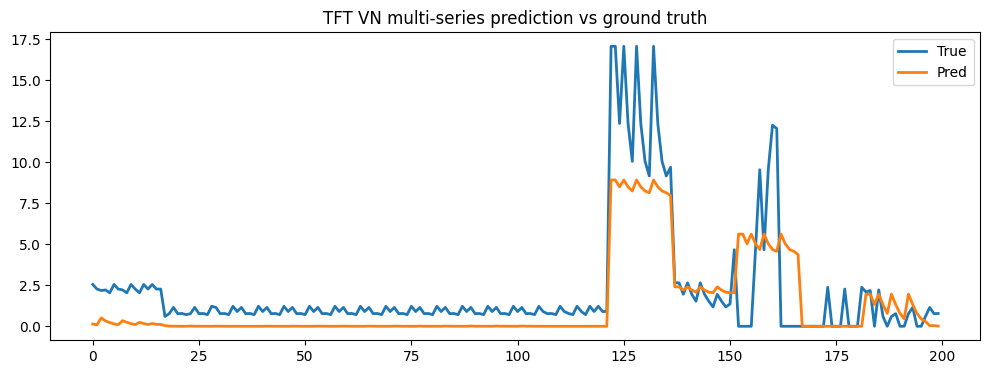

In [76]:
# Cell 6: Evaluate quick metrics + plot

best_model = TemporalFusionTransformer.load_from_checkpoint(best_ckpt)
preds = best_model.predict(test_loader, mode="prediction")

y_true = []
for _, batch_y in test_loader:
    target = batch_y[0] if isinstance(batch_y, tuple) else batch_y
    y_true.append(target.detach().cpu().numpy())

y_true = np.concatenate([arr.flatten() for arr in y_true], axis=0)
y_pred = preds.detach().cpu().numpy().reshape(-1)

n = min(len(y_true), len(y_pred))
y_true = y_true[:n]
y_pred = y_pred[:n]

# Loai bo NaN/Inf truoc khi tinh metric
mask = np.isfinite(y_true) & np.isfinite(y_pred)
removed = int((~mask).sum())
if removed > 0:
    print(f"Da loai {removed} diem NaN/Inf truoc khi danh gia.")

y_true = y_true[mask]
y_pred = y_pred[mask]

if len(y_true) == 0:
    raise ValueError("Khong con diem hop le de tinh metric sau khi loc NaN/Inf.")

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

plt.figure(figsize=(12, 4))
plt.plot(y_true[-200:], label="True", linewidth=2)
plt.plot(y_pred[-200:], label="Pred", linewidth=2)
plt.title("TFT VN multi-series prediction vs ground truth")
plt.legend()
plt.show()